# Baseline model

Notebook objectives:

- load the feature-engineered dataset;
- define input features and target variable;
- split the data using a time-based train/test split;
- train a simple baseline regression model;
- evaluate the model with MAE, RMSE, and R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data_path = "../data/processed/electricity_weather_features.csv"

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier,year,month,day_of_week,day_of_year,is_weekend,temperature_range,temperature_mean,heating_degree_days,cooling_degree_days
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False,2006,12,5,350,True,5.6,7.80,10.20,0.0
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False,2006,12,6,351,True,7.7,9.45,8.55,0.0
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False,2006,12,0,352,False,8.3,10.85,7.15,0.0
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False,2006,12,1,353,False,5.0,4.70,13.30,0.0
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False,2006,12,2,354,False,6.1,4.15,13.85,0.0


## Feature and target selection

We define the target variable to predict and select the input features used by the baseline model.

In [ ]:
target_column = "daily_consumption"

feature_columns = [
    "AWND",
    "PRCP",
    "TMAX",
    "TMIN",
    "month",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "temperature_range",
    "temperature_mean",
    "heating_degree_days",
    "cooling_degree_days"
]

X = df[feature_columns]
y = df[target_column]

X.head()

,AWND,PRCP,temperature_mean,heating_degree_days,cooling_degree_days,day_of_week,day_of_year,is_weekend
0,2.5,0.0,7.80,10.20,0.0,5,350,True
1,2.6,0.0,9.45,8.55,0.0,6,351,True
2,2.4,0.0,10.85,7.15,0.0,0,352,False
3,2.4,0.0,4.70,13.30,0.0,1,353,False
4,2.4,0.0,4.15,13.85,0.0,2,354,False


## Time-based train/test split

Since the dataset is ordered by date, we use a time-based split. The model is trained on older observations and tested on more recent observations.

In [4]:
split_date = "2010-01-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1110, 8), (323, 8), (1110,), (323,))

In [5]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Baseline predictions

We use the trained linear regression model to predict daily consumption on the test period.

In [6]:
y_pred = baseline_model.predict(X_test)

y_pred[:10]

/Users/marouaneharouch/Documents/DTY/projet/projet-electricity-weather/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/marouaneharouch/Documents/DTY/projet/projet-electricity-weather/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/marouaneharouch/Documents/DTY/projet/projet-electricity-weather/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


array([1768.6762894 , 2277.49492424, 2387.1017815 , 1969.54669863,
       1965.14407378, 1876.79009277, 1817.14299985, 1916.80567417,
       2316.24731171, 2375.0347095 ])

## Baseline model evaluation

We compare predicted daily consumption values with the true values from the test period.

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(344.6973340487437, np.float64(442.7121929924981), 0.23293524944673005)

In [8]:
baseline_results = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

baseline_results

,metric,value
0,MAE,344.697334
1,RMSE,442.712193
2,R2,0.232935


In [9]:
predictions_df = pd.DataFrame({
    "date": df.loc[test_mask, "date"],
    "actual": y_test,
    "predicted": y_pred
})

predictions_df.head()

,date,actual,predicted
1110,2010-01-01,1224.252,1768.676289
1111,2010-01-02,1308.836,2277.494924
1112,2010-01-03,2083.454,2387.101781
1113,2010-01-04,1604.132,1969.546699
1114,2010-01-05,2219.780,1965.144074


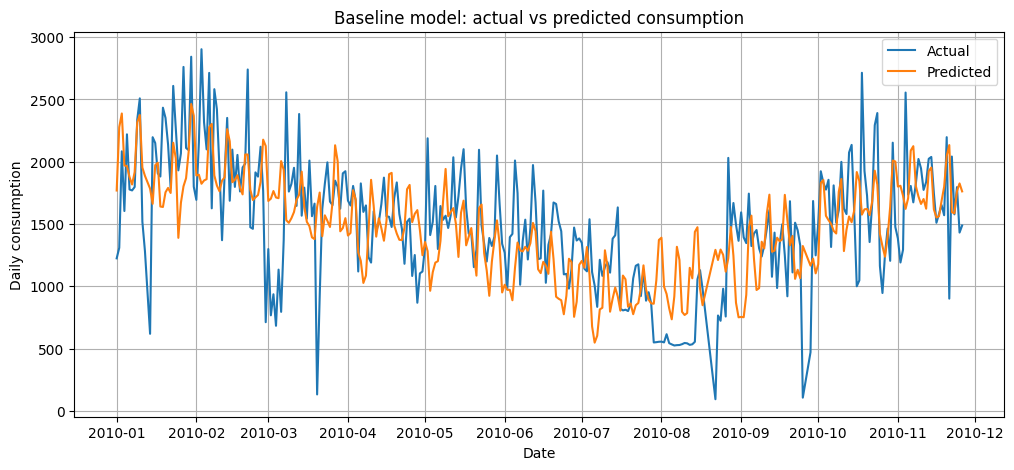

In [10]:
plt.figure(figsize=(12,5))

plt.plot(predictions_df["date"], predictions_df["actual"], label= "Actual")
plt.plot(predictions_df["date"], predictions_df["predicted"], label= 'Predicted')

plt.title("Baseline model: actual vs predicted consumption")
plt.xlabel("Date")
plt.ylabel("Daily consumption")
plt.legend()
plt.grid(True)

plt.show()

The baseline model captures part of the seasonal trend, but it does not reproduce short-term variations very well. Predictions are smoother than the actual values, which is expected from a simple linear regression model.

The model tends to miss sharp peaks and unusually low values. This confirms that the baseline is useful as a reference point, but more advanced models or additional temporal features may be needed to improve performance.

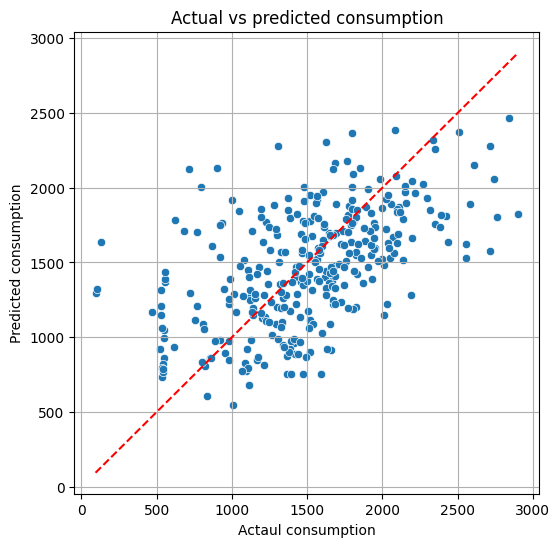

In [11]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x= predictions_df["actual"],
    y= predictions_df["predicted"]
)

plt.plot(
    [predictions_df["actual"].min(), predictions_df["actual"].max()],
    [predictions_df["actual"].min(), predictions_df["actual"].max()],
    color= "red",
    linestyle= "--"
)

plt.title("Actual vs predicted consumption")
plt.xlabel("Actaul consumption")
plt.ylabel("Predicted consumption")
plt.grid(True)

plt.show()

The actual vs predicted plot confirms that the baseline model captures part of the overall relationship, but prediction errors remain substantial.

The model tends to overestimate some low-consumption days and underestimate some high-consumption days. This behavior is consistent with the relatively low R² score and shows the limits of a simple linear regression baseline.

In [12]:
coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": baseline_model.coef_
})

coefficients.sort_values("coefficient")

,feature,coefficient
2,temperature_mean,-28.493773
4,cooling_degree_days,-24.490801
0,AWND,-3.615513
1,PRCP,-2.719626
6,day_of_year,0.517710
5,day_of_week,1.757647
3,heating_degree_days,4.002973
7,is_weekend,322.320846


The coefficient table should be interpreted carefully because several temperature-related features are strongly related to each other. `TMAX`, `TMIN`, `temperature_mean`, `temperature_range`, `heating_degree_days`, and `cooling_degree_days` contain overlapping information.

This multicollinearity can make individual linear regression coefficients unstable or counter-intuitive. For this reason, the baseline model is mainly used as a performance reference rather than a fully interpretable final model.

## Baseline model conclusion

The linear regression baseline provides a first reference point for the forecasting task.

On the test period, the model reaches:

- MAE: about 345 units;
- RMSE: about 443 units;
- R²: about 0.23.

The model captures part of the seasonal trend, but its predictions are smoother than the actual consumption values. It tends to miss sharp peaks and some unusually low values.

The coefficient analysis is useful but should be interpreted carefully because several temperature-related features are strongly correlated with each other.

Overall, this baseline is not a final model. Its purpose is to provide a simple benchmark that future models must improve upon.